In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors as mcolors
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

try:
    from Ipython.display import display
except ImportError:
    def display(obj):
        print(obj)
plt.rcParams.update({
    "figure.figsize": (14, 8),
    "figure.dpi": 140,
    "axes.titlesize": 16,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "DejaVu Sans",
})

PALETTE = {
    "paper": "#f7f4ed",
    "panel": "#efe8da",
    "ink": "#1f2a33",
    "muted": "#5c6770",
    "grid": "#c9bfa9",
    "accent": "#b55239",
    "accent2": "#2b7a78",
    "highlight": "#d6a84f",
}

SCORE_CMAP = mcolors.LinearSegmentedColormap.from_list("score_map", ["#113b5c", "#3b7a57", "#d6a84f", "#b55239"])
SCORE_CMAP.set_bad(PALETTE["panel"])
DELTA_CMAP = mcolors.LinearSegmentedColormap.from_list("delta_map", [PALETTE["accent"], "#f7f4ed", PALETTE["accent2"]])
DELTA_NORM = mcolors.TwoSlopeNorm(vmin=-0.9, vcenter = 0.0, vmax = 0.9)

def style_axes(ax , title = None, subtitle = None, title_pad=28):
    ax.set_facecolor(PALETTE["panel"])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis = "y", color=PALETTE["grid"], linewidth=0.9, alpha=0.45)
    ax.tick_params(colors=PALETTE["ink"])
    if title is not None:
        ax.set_title(title, loc="left", color=PALETTE["ink"], pad=title_pad, fontweight="bold")
    if subtitle is not None:
        ax.text(
            0.0,
            1.0,
            subtitle,
            transform=ax.transAxes,
            fontsize=10,
            color=PALETTE["muted"],
            va="bottom",
            ha="left",
        )
    return ax
rng = np.random.default_rng(7)

In [5]:
DATA_PATH = Path("/Users/praneetgogoi/Documents/corporate-greenwashing-trend-model/Greenwashing_Score_Data.xlsx")
df = (
    pd.read_excel(DATA_PATH)
    .rename(columns=lambda c: str(c).strip())
    .assign(
        COMPANY_NAME=lambda d: d["COMPANY_NAME"].astype(str).str.strip(),
        YEAR=lambda d: d["YEAR"].astype(int),
        GW_SCORE=lambda d: d["GW_SCORE"].astype(float),
        USED_FOR_ANALYSIS=lambda d: d["USED_FOR_ANALYSIS"].astype(bool),
    )
)

years = np.arange(df["YEAR"].min(), df["YEAR"].max() + 1)

score_distribution = (
    df["GW_SCORE"]
    .value_counts()
    .sort_index()
    .rename_axis("score")
    .reset_index(name="count")
)
score_distribution["probability"] = score_distribution["count"] / len(df)

year_summary = (
    df.groupby("YEAR")
    .agg(
        observations=("GW_SCORE", "size"),
        mean_score=("GW_SCORE", "mean"),
        median_score=("GW_SCORE", "median"),
        q10=("GW_SCORE", lambda s: s.quantile(0.10)),
        q25=("GW_SCORE", lambda s: s.quantile(0.25)),
        q75=("GW_SCORE", lambda s: s.quantile(0.75)),
        q90=("GW_SCORE", lambda s: s.quantile(0.90)),
        analysis_share=("USED_FOR_ANALYSIS", "mean"),
    )
    .reindex(years)
)

company_features = (
    df.groupby("COMPANY_NAME")
    .agg(
        observations=("GW_SCORE", "size"),
        first_year=("YEAR", "min"),
        last_year=("YEAR", "max"),
        mean_score=("GW_SCORE", "mean"),
        score_volatility=("GW_SCORE", "std"),
        used_share=("USED_FOR_ANALYSIS", "mean"),
    )
    .assign(
        score_volatility=lambda d: d["score_volatility"].fillna(0.0),
        span=lambda d: d["last_year"] - d["first_year"] + 1,
        window_density=lambda d: d["observations"] / d["span"],
    )
)

panel_density = len(df) / (df["COMPANY_NAME"].nunique() * len(years))
score_entropy_bits = -(score_distribution["probability"] * np.log2(score_distribution["probability"])).sum()
effective_score_states = 2 ** score_entropy_bits

overview = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Unique companies",
            "Calendar span",
            "Distinct score states",
            "Panel occupancy",
            "Shannon entropy (bits)",
            "Effective score states",
            "Share used for analysis",
            "Share of companies with a single observation",
        ],
        "Value": [
            f"{len(df):,}",
            f"{df['COMPANY_NAME'].nunique():,}",
            f"{years.min()}-{years.max()} ({len(years)} years)",
            f"{score_distribution.shape[0]}",
            f"{panel_density:.1%}",
            f"{score_entropy_bits:.3f}",
            f"{effective_score_states:.2f}",
            f"{df['USED_FOR_ANALYSIS'].mean():.1%}",
            f"{company_features['observations'].eq(1).mean():.1%}",
        ],
    }
)

display(overview)

display(
    year_summary.style.format(
        {
            "mean_score": "{:.3f}",
            "median_score": "{:.3f}",
            "q10": "{:.3f}",
            "q25": "{:.3f}",
            "q75": "{:.3f}",
            "q90": "{:.3f}",
            "analysis_share": "{:.1%}",
        }
    )
)

display(
    company_features.sort_values(["observations", "mean_score"], ascending=[False, False])
    .head(12)
    .style.format(
        {
            "mean_score": "{:.3f}",
            "score_volatility": "{:.3f}",
            "used_share": "{:.1%}",
            "window_density": "{:.2f}",
        }
    )
)

                                         Metric                 Value
0                                          Rows                   595
1                              Unique companies                   215
2                                 Calendar span  2011-2023 (13 years)
3                         Distinct score states                    22
4                               Panel occupancy                 21.3%
5                        Shannon entropy (bits)                 3.760
6                        Effective score states                 13.55
7                       Share used for analysis                 63.4%
8  Share of companies with a single observation                 44.2%


/var/folders/s9/9mvfxgrs1wb9r54tth0nzksm0000gn/T/ipykernel_2925/3942660079.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


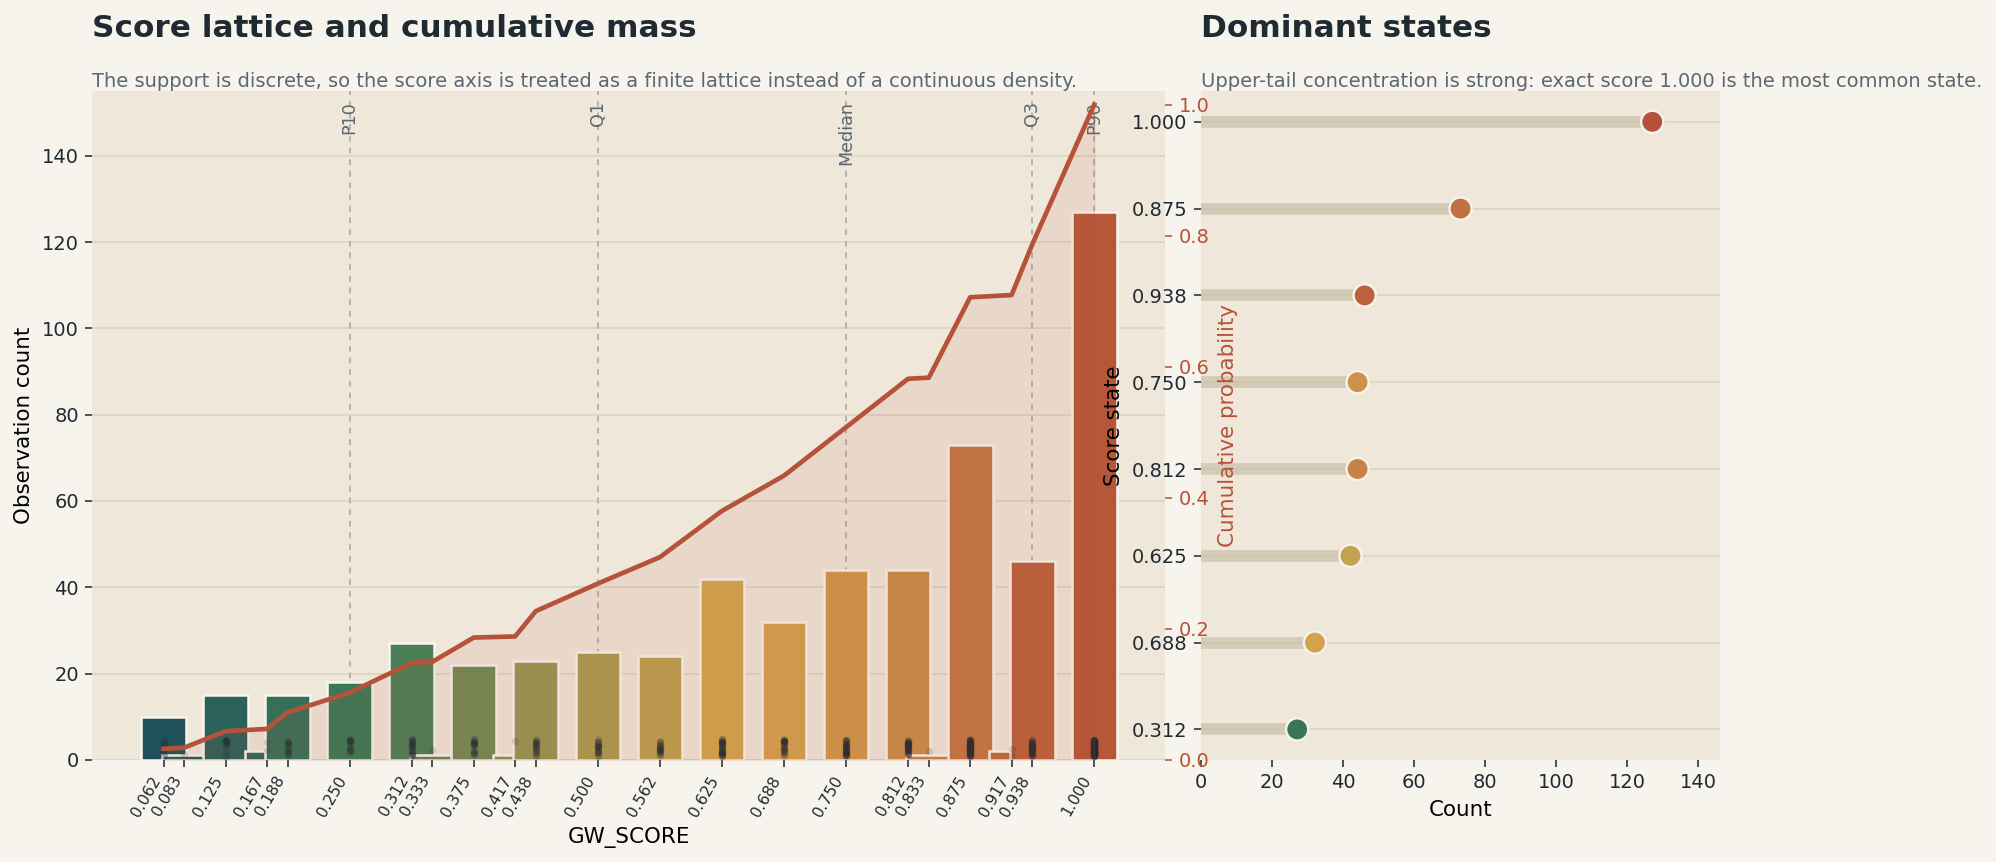

In [7]:
quantiles = df["GW_SCORE"].quantile([0.10, 0.25, 0.50, 0.75, 0.90])
score_positions = score_distribution["score"].to_numpy()
score_counts = score_distribution["count"].to_numpy()
cum_probability = score_distribution["probability"].cumsum().to_numpy()

fig = plt.figure(figsize=(15, 6.2), facecolor=PALETTE["paper"])
gs = GridSpec(1, 12, figure=fig, wspace=0.35)

ax = fig.add_subplot(gs[:, :8])
ax_rank = fig.add_subplot(gs[:, 8:])

style_axes(
    ax,
    "Score lattice and cumulative mass",
    "The support is discrete, so the score axis is treated as a finite lattice instead of a continuous density.",
)
ax.grid(axis="x", visible=False)

bar_colors = SCORE_CMAP(np.linspace(0.12, 0.98, len(score_positions)))
ax.bar(
    score_positions,
    score_counts,
    width=0.045,
    color=bar_colors,
    edgecolor=PALETTE["paper"],
    linewidth=1.3,
    zorder=3,
)

rug_y = rng.uniform(0.8, 4.8, len(df))
ax.scatter(
    df["GW_SCORE"],
    rug_y,
    s=14,
    color=PALETTE["ink"],
    alpha=0.16,
    linewidth=0,
    zorder=4,
)

y_max = score_counts.max() * 1.22
ax.set_ylim(0, y_max)
for q, label in zip(quantiles.values, ["P10", "Q1", "Median", "Q3", "P90"]):
    ax.axvline(q, color=PALETTE["ink"], linestyle=(0, (3, 3)), linewidth=1.0, alpha=0.28, zorder=1)
    ax.text(q, y_max * 0.985, label, rotation=90, va="top", ha="center", fontsize=9, color=PALETTE["muted"])

ax.set_xlabel("GW_SCORE")
ax.set_ylabel("Observation count")
ax.set_xticks(score_positions)
ax.set_xticklabels([f"{x:.3f}" for x in score_positions], rotation=60, ha="right", fontsize=8)

ax_cdf = ax.twinx()
ax_cdf.plot(score_positions, cum_probability, color=PALETTE["accent"], linewidth=2.4, zorder=5)
ax_cdf.fill_between(score_positions, 0, cum_probability, color=PALETTE["accent"], alpha=0.10, zorder=2)
ax_cdf.set_ylim(0, 1.02)
ax_cdf.set_ylabel("Cumulative probability", color=PALETTE["accent"])
ax_cdf.tick_params(axis="y", colors=PALETTE["accent"])
for spine in ax_cdf.spines.values():
    spine.set_visible(False)

style_axes(
    ax_rank,
    "Dominant states",
    "Upper-tail concentration is strong: exact score 1.000 is the most common state.",
)
top_states = score_distribution.sort_values("count", ascending=False).head(8).sort_values("count")
ax_rank.hlines(
    y=np.arange(len(top_states)),
    xmin=0,
    xmax=top_states["count"],
    color=PALETTE["grid"],
    linewidth=6,
    alpha=0.7,
)
ax_rank.scatter(
    top_states["count"],
    np.arange(len(top_states)),
    s=130,
    c=top_states["score"],
    cmap=SCORE_CMAP,
    vmin=0,
    vmax=1,
    edgecolor=PALETTE["paper"],
    linewidth=1.2,
    zorder=3,
)
ax_rank.set_yticks(np.arange(len(top_states)))
ax_rank.set_yticklabels([f"{s:.3f}" for s in top_states["score"]])
ax_rank.set_xlabel("Count")
ax_rank.set_ylabel("Score state")
ax_rank.set_xlim(0, top_states["count"].max() * 1.15)

plt.tight_layout()
plt.savefig("score_distribution.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())

plt.show()

/var/folders/s9/9mvfxgrs1wb9r54tth0nzksm0000gn/T/ipykernel_2925/3154447762.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


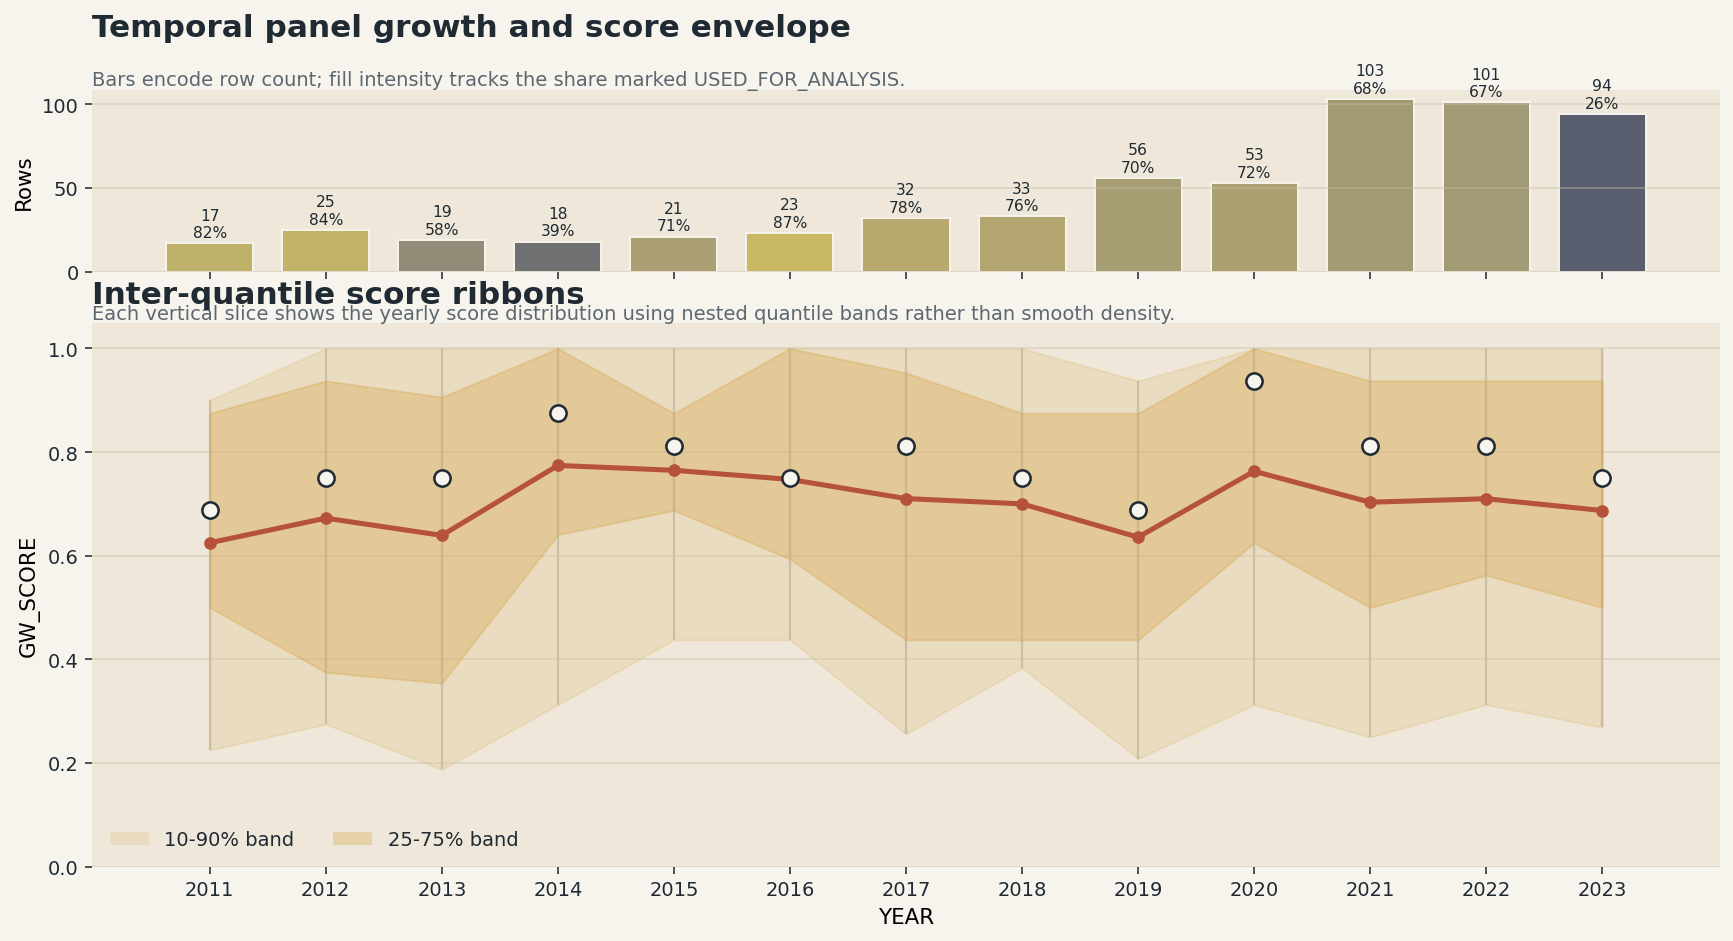

In [8]:
fig = plt.figure(figsize = (15 , 7.2), facecolor = PALETTE["paper"])
gs = GridSpec(2,1,height_ratios = [1.0, 3.0], hspace = 0.14, figure = fig)

ax_top = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0], sharex=ax_top)

style_axes(
    ax_top,
    "Temporal panel growth and score envelope",
    "Bars encode row count; fill intensity tracks the share marked USED_FOR_ANALYSIS.",
)

ax_top.grid(axis="x", visible=False)

bar_colors = plt.cm.cividis(year_summary["analysis_share"].fillna(0).to_numpy() * 0.75 + 0.15)
ax_top.bar(
    years,
    year_summary["observations"],
    width=0.75,
    color=bar_colors,
    edgecolor=PALETTE["paper"],
    linewidth=1.0,
)
for year, row in year_summary.iterrows():
    ax_top.text(
        year,
        row["observations"] + 2.0,
        f"{int(row['observations'])}\n{row['analysis_share']:.0%}",
        ha="center",
        va="bottom",
        fontsize=8,
        color=PALETTE["ink"],
    )
ax_top.set_ylabel("Rows")
ax_top.tick_params(axis="x", labelbottom=False)

style_axes(
    ax,
    "Inter-quantile score ribbons",
    "Each vertical slice shows the yearly score distribution using nested quantile bands rather than smooth density.",
    title_pad=10,
)
ax.fill_between(years, year_summary["q10"], year_summary["q90"], color=PALETTE["highlight"], alpha=0.18, zorder=1)
ax.fill_between(years, year_summary["q25"], year_summary["q75"], color=PALETTE["highlight"], alpha=0.35, zorder=2)
ax.plot(years, year_summary["mean_score"], color=PALETTE["accent"], linewidth=2.6, marker="o", markersize=5.5, zorder=4)
ax.scatter(years, year_summary["median_score"], s=70, color=PALETTE["paper"], edgecolor=PALETTE["ink"], linewidth=1.3, zorder=5)
for year in years:
    row = year_summary.loc[year]
    ax.vlines(year, row["q10"], row["q90"], color=PALETTE["ink"], alpha=0.18, linewidth=1.2, zorder=0)

ax.set_ylabel("GW_SCORE")
ax.set_xlabel("YEAR")
ax.set_xticks(years)
ax.set_ylim(0, 1.05)

legend_handles = [
    Rectangle((0, 0), 1, 1, facecolor=PALETTE["highlight"], alpha=0.18, edgecolor="none", label="10-90% band"),
    Rectangle((0, 0), 1, 1, facecolor=PALETTE["highlight"], alpha=0.35, edgecolor="none", label="25-75% band"),
]
ax.legend(handles=legend_handles, loc="lower left", frameon=False, ncol=2, labelcolor=PALETTE["ink"])

plt.tight_layout()
plt.savefig("temporal_trends.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

/var/folders/s9/9mvfxgrs1wb9r54tth0nzksm0000gn/T/ipykernel_2925/3639026138.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


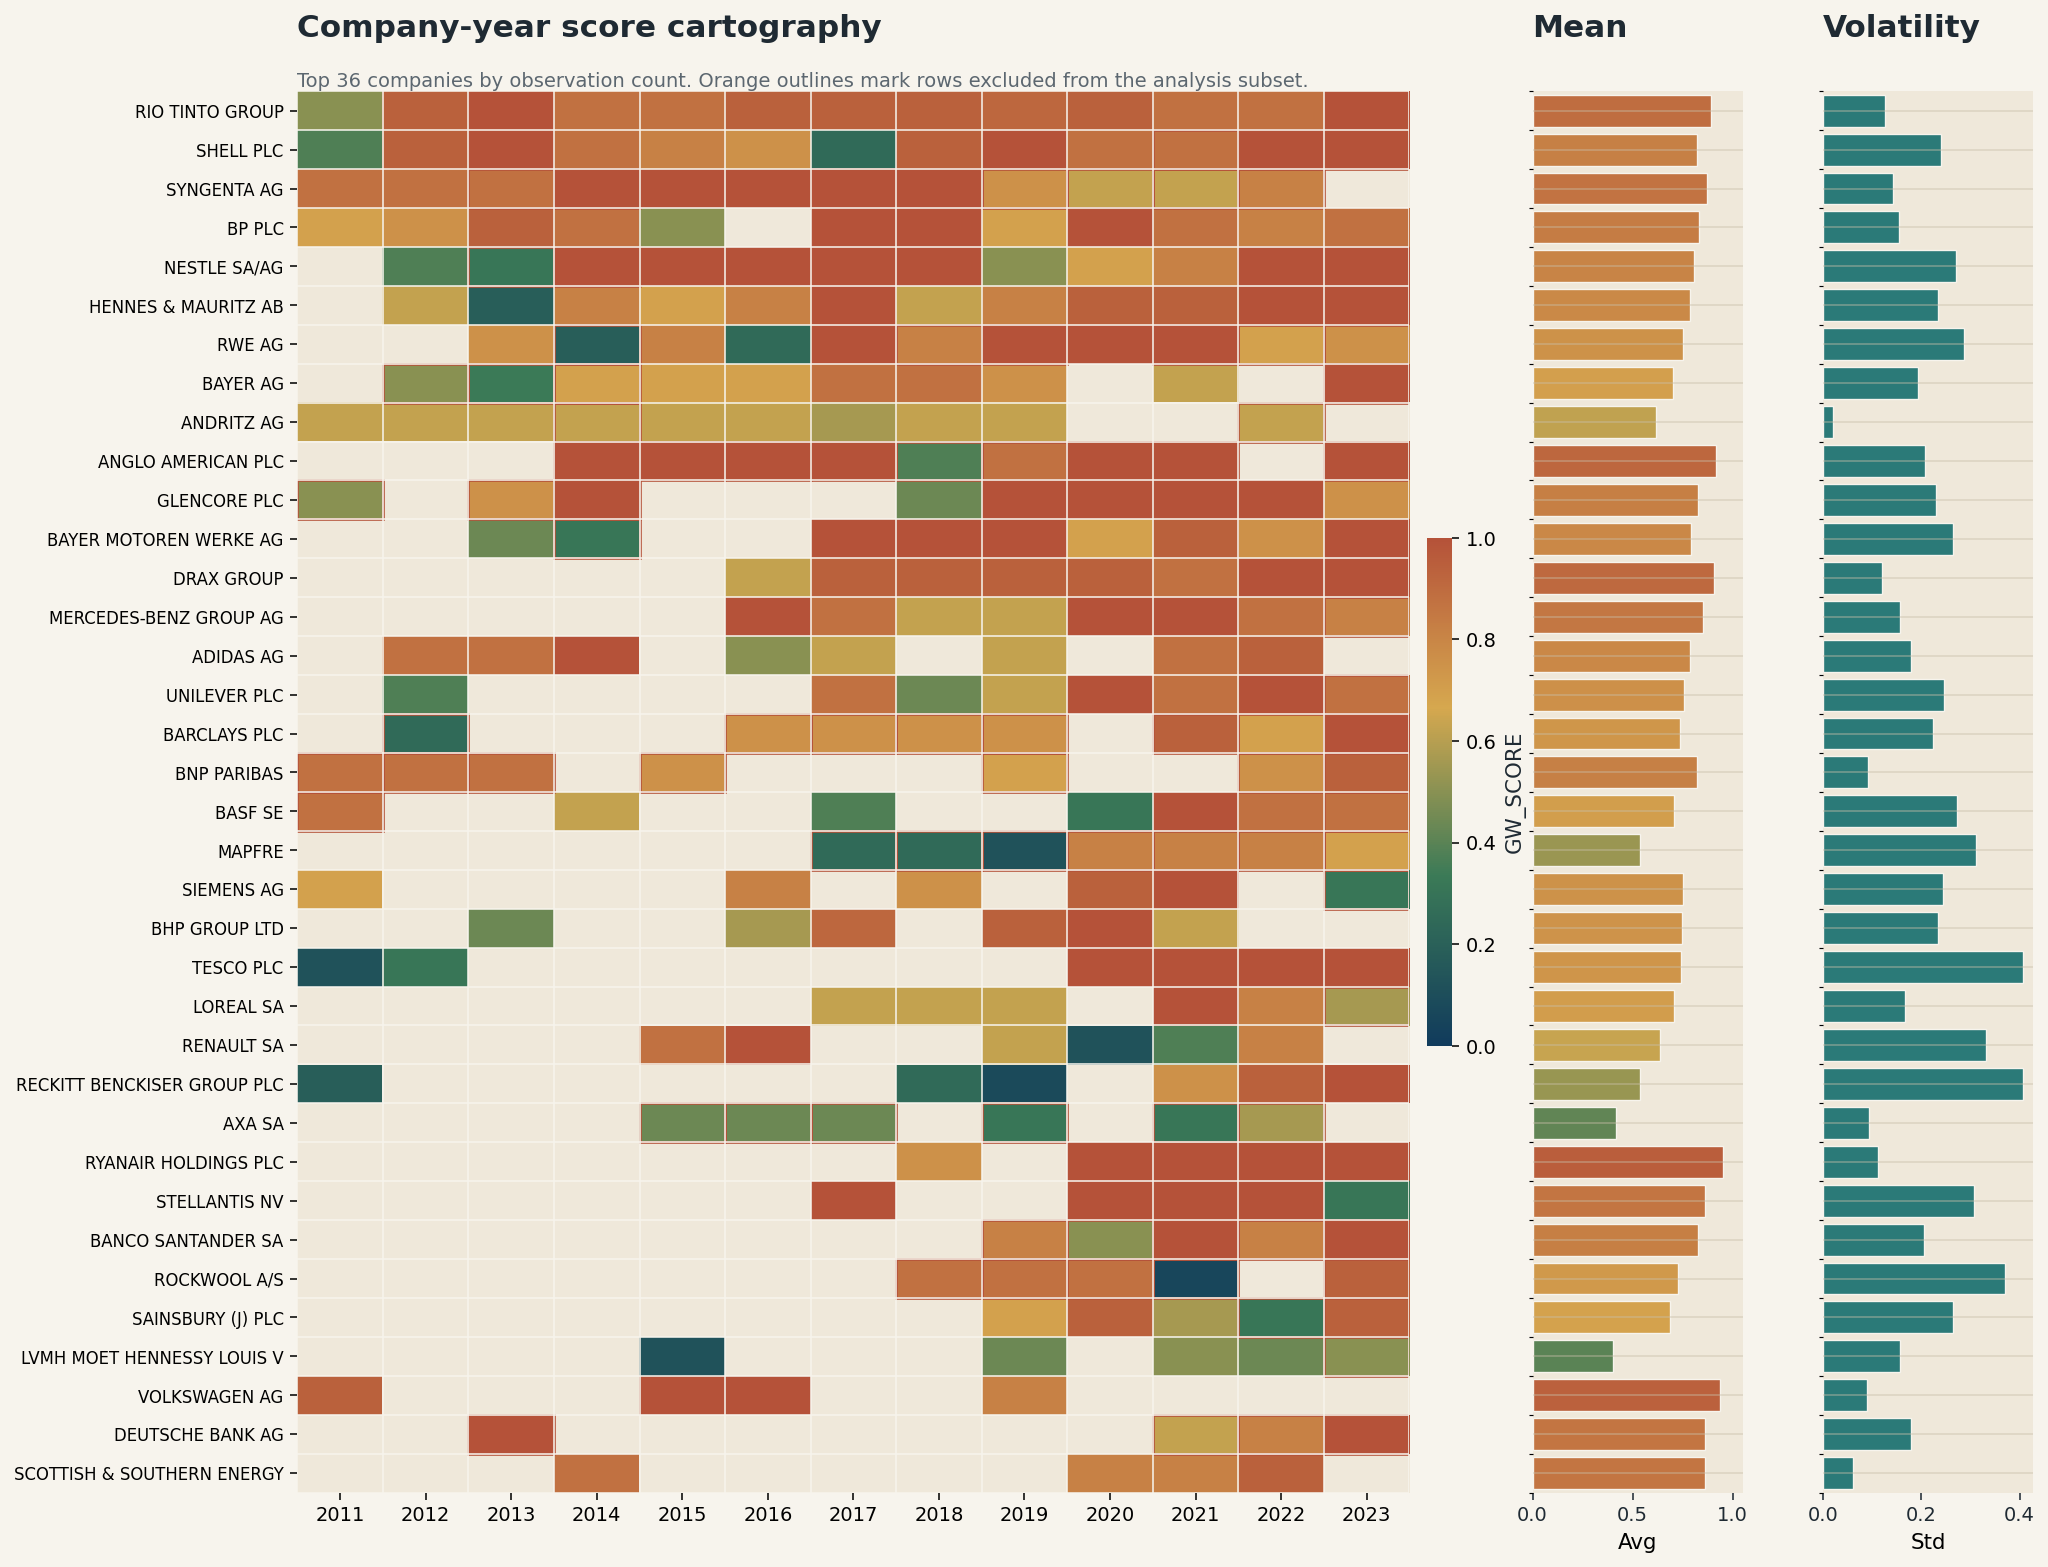

In [10]:
focus_companies = (
    company_features.sort_values(["observations", "mean_score"], ascending=[False, False])
    .head(36)
    .index
)

score_grid = (
    df[df["COMPANY_NAME"].isin(focus_companies)]
    .pivot(index="COMPANY_NAME", columns="YEAR", values="GW_SCORE")
    .reindex(index=focus_companies, columns=years)
)
used_grid = (
    df[df["COMPANY_NAME"].isin(focus_companies)]
    .pivot(index="COMPANY_NAME", columns="YEAR", values="USED_FOR_ANALYSIS")
    .reindex(index=focus_companies, columns=years)
)

fig = plt.figure(figsize=(16, 13), facecolor=PALETTE["paper"])
gs = GridSpec(1, 24, figure=fig, wspace=0.12)

ax = fig.add_subplot(gs[:, :16])
ax_mean = fig.add_subplot(gs[:, 17:20], sharey=ax)
ax_vol = fig.add_subplot(gs[:, 21:24], sharey=ax)

heat = ax.imshow(np.ma.masked_invalid(score_grid.to_numpy()), aspect="auto", cmap=SCORE_CMAP, vmin=0, vmax=1)
ax.set_facecolor(PALETTE["panel"])
ax.set_title(
    "Company-year score cartography",
    loc="left",
    fontsize=16,
    fontweight="bold",
    color=PALETTE["ink"],
    pad=28,
)
ax.text(
    0.0,
    1.0,
    "Top 36 companies by observation count. Orange outlines mark rows excluded from the analysis subset.",
    transform=ax.transAxes,
    fontsize=10,
    color=PALETTE["muted"],
    va="bottom",
    ha="left",
)
ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years)
ax.set_yticks(np.arange(len(focus_companies)))
ax.set_yticklabels([name[:30] for name in focus_companies], fontsize=8.5)
ax.set_xticks(np.arange(-0.5, len(years), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(focus_companies), 1), minor=True)
ax.grid(which="minor", color=PALETTE["paper"], linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)
for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(score_grid.shape[0]):
    for j in range(score_grid.shape[1]):
        flag = used_grid.iat[i, j]
        if pd.notna(flag) and (not bool(flag)):
            ax.add_patch(
                Rectangle(
                    (j - 0.5, i - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor=PALETTE["accent"],
                    linewidth=1.35,
                )
            )

cbar = fig.colorbar(heat, ax=ax, fraction=0.022, pad=0.015)
cbar.set_label("GW_SCORE", color=PALETTE["ink"])
cbar.outline.set_visible(False)

mean_values = company_features.loc[focus_companies, "mean_score"].to_numpy()
style_axes(ax_mean, "Mean", None)
ax_mean.barh(
    np.arange(len(focus_companies)),
    mean_values,
    color=SCORE_CMAP(mean_values),
    height=0.82,
    edgecolor=PALETTE["paper"],
    linewidth=0.7,
)
ax_mean.set_xlim(0, 1.05)
ax_mean.set_xlabel("Avg")
ax_mean.tick_params(axis="y", left=False, labelleft=False)

vol_values = company_features.loc[focus_companies, "score_volatility"].to_numpy()
style_axes(ax_vol, "Volatility", None)
ax_vol.barh(
    np.arange(len(focus_companies)),
    vol_values,
    color=PALETTE["accent2"],
    height=0.82,
    edgecolor=PALETTE["paper"],
    linewidth=0.7,
)
ax_vol.set_xlabel("Std")
ax_vol.tick_params(axis="y", left=False, labelleft=False)

plt.tight_layout()
plt.savefig("company_year_grid.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

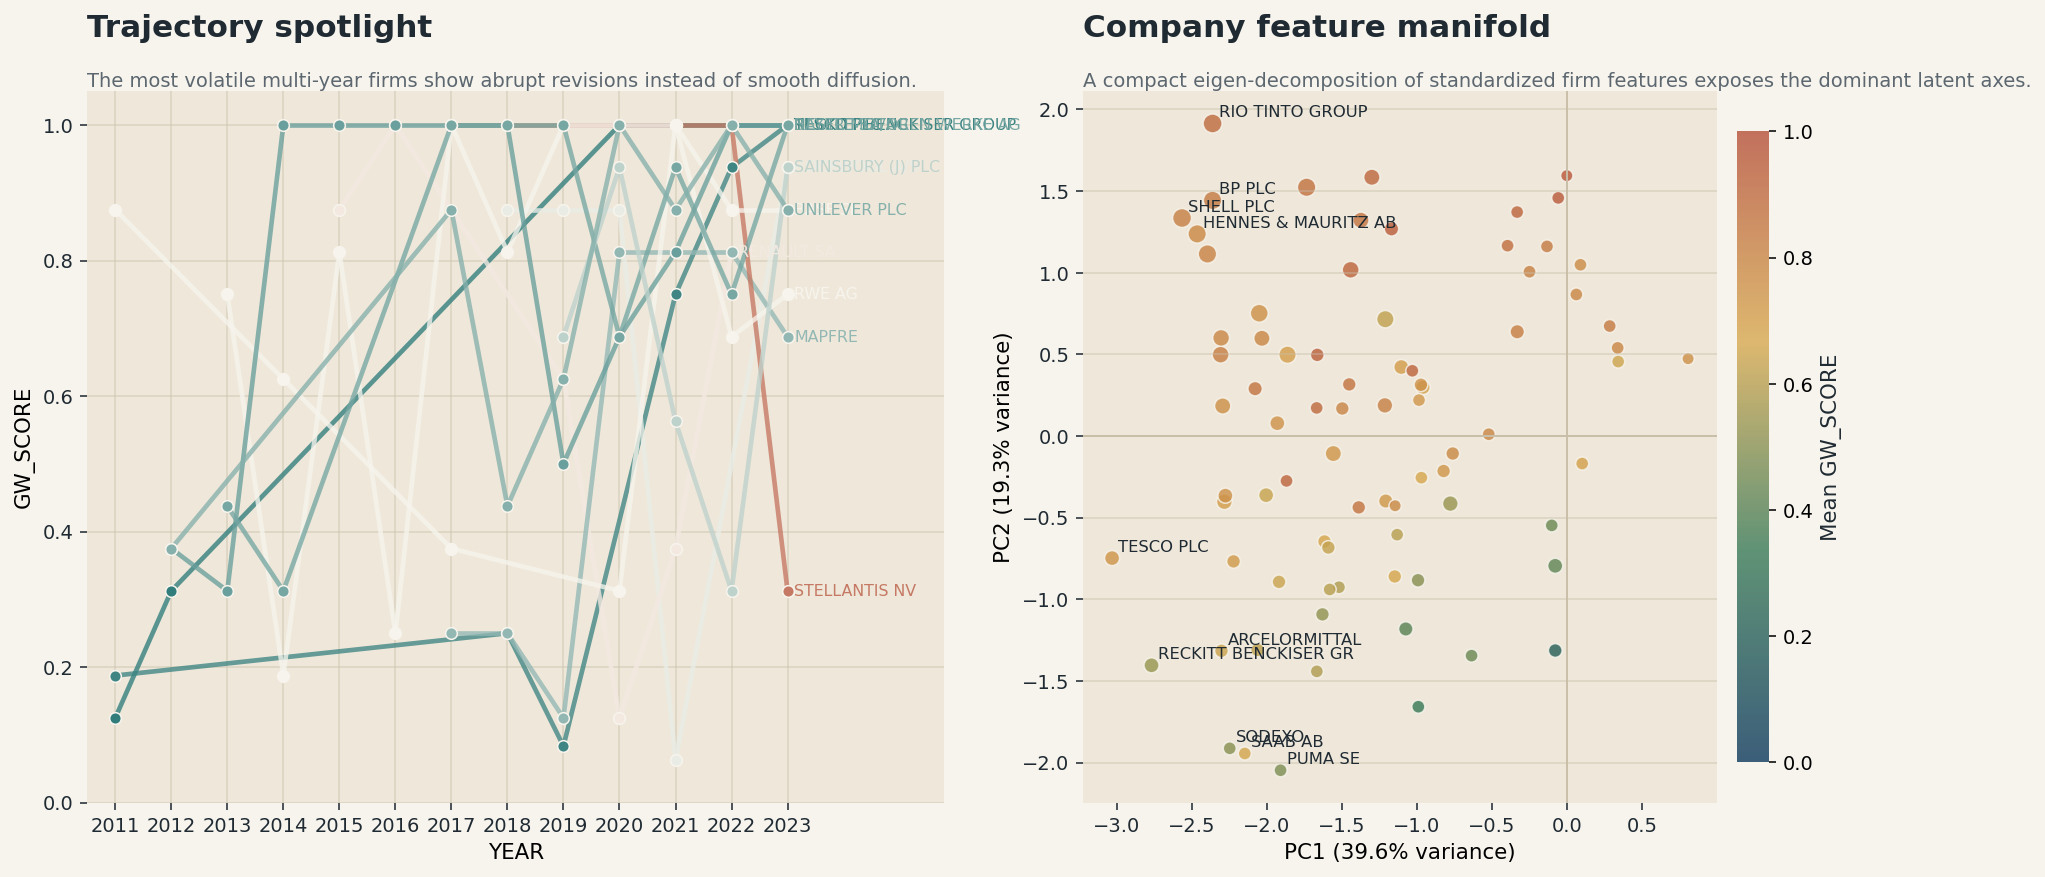

In [11]:
feature_cols = ["mean_score", "score_volatility", "observations", "window_density", "used_share"]
Z = (company_features[feature_cols] - company_features[feature_cols].mean()) / company_features[feature_cols].std(ddof=0)

Sigma = np.cov(Z.to_numpy(), rowvar=False)
eigvals, eigvecs = np.linalg.eigh(Sigma)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]
variance_share = eigvals / eigvals.sum()

projection = pd.DataFrame(
    Z.to_numpy() @ eigvecs[:, :2],
    index=company_features.index,
    columns=["PC1", "PC2"],
).join(company_features[["observations", "mean_score", "score_volatility"]])

trajectory_names = (
    company_features.loc[company_features["observations"] >= 5]
    .sort_values(["score_volatility", "observations"], ascending=[False, False])
    .head(12)
    .index
)

fig = plt.figure(figsize=(15.5, 6.6), facecolor=PALETTE["paper"])
gs = GridSpec(1, 2, figure=fig, width_ratios=[1.25, 1.0], wspace=0.18)

ax = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

style_axes(
    ax,
    "Trajectory spotlight",
    "The most volatile multi-year firms show abrupt revisions instead of smooth diffusion.",
)
ax.grid(axis="x", color=PALETTE["grid"], linewidth=0.9, alpha=0.45)
for name in trajectory_names:
    sub = df.loc[df["COMPANY_NAME"] == name].sort_values("YEAR")
    x = sub["YEAR"].to_numpy()
    y = sub["GW_SCORE"].to_numpy()
    delta = y[-1] - y[0]
    color = DELTA_CMAP(DELTA_NORM(delta))
    points = np.column_stack([x, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    ax.add_collection(LineCollection(segments, colors=[color] * len(segments), linewidths=2.4, alpha=0.78))
    ax.scatter(x, y, s=36, color=color, edgecolor=PALETTE["paper"], linewidth=0.8, zorder=3)
    ax.text(x[-1] + 0.12, y[-1], name[:24], fontsize=8.2, color=color, va="center")

ax.set_xlim(years.min() - 0.5, years.max() + 2.8)
ax.set_ylim(0, 1.05)
ax.set_xticks(years)
ax.set_ylabel("GW_SCORE")
ax.set_xlabel("YEAR")

style_axes(
    ax2,
    "Company feature manifold",
    "A compact eigen-decomposition of standardized firm features exposes the dominant latent axes.",
)
ax2.axhline(0, color=PALETTE["grid"], linewidth=1.0)
ax2.axvline(0, color=PALETTE["grid"], linewidth=1.0)

focus_projection = projection.sort_values("observations", ascending=False).head(80)
scatter = ax2.scatter(
    focus_projection["PC1"],
    focus_projection["PC2"],
    s=30 + focus_projection["observations"] * 5,
    c=focus_projection["mean_score"],
    cmap=SCORE_CMAP,
    vmin=0,
    vmax=1,
    alpha=0.82,
    edgecolor=PALETTE["paper"],
    linewidth=0.8,
)

label_candidates = (
    focus_projection.assign(radius=lambda d: np.hypot(d["PC1"], d["PC2"]))
    .sort_values("radius", ascending=False)
    .head(10)
)
for name, row in label_candidates.iterrows():
    ax2.text(row["PC1"] + 0.04, row["PC2"] + 0.04, name[:20], fontsize=8.4, color=PALETTE["ink"])

ax2.set_xlabel(f"PC1 ({variance_share[0]:.1%} variance)")
ax2.set_ylabel(f"PC2 ({variance_share[1]:.1%} variance)")

cbar = fig.colorbar(scatter, ax=ax2, fraction=0.046, pad=0.03)
cbar.set_label("Mean GW_SCORE", color=PALETTE["ink"])
cbar.outline.set_visible(False)

plt.show()

loadings = pd.DataFrame(
    {
        "Feature": feature_cols,
        "PC1_loading": eigvecs[:, 0],
        "PC2_loading": eigvecs[:, 1],
    }
).sort_values("PC1_loading", key=np.abs, ascending=False)

display(loadings.style.format({"PC1_loading": "{:.3f}", "PC2_loading": "{:.3f}"}))

In [12]:
!pip install panel plotly pandas numpy

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [19]:
df.columns

Index(['COMPANY_NAME', 'YEAR', 'GW_SCORE', 'USED_FOR_ANALYSIS'], dtype='str')

In [31]:
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np


df = pd.read_excel("Greenwashing_Score_Data.xlsx")
df.columns = df.columns.str.strip().str.upper()

df["YEAR"] = df["YEAR"].astype(int)
df["GW_SCORE"] = df["GW_SCORE"].astype(float)

app = dash.Dash(__name__)
server = app.server


BG = "#0f172a"
CARD = "#111827"
ACCENT = "#f59e0b"
TEXT = "#e5e7eb"

app.layout = html.Div(
    style={"backgroundColor": BG, "padding": "30px", "fontFamily": "Arial"},
    children=[

        html.H1(
            "GW Score Structural Intelligence Dashboard",
            style={"color": TEXT}
        ),

        html.Div([
            dcc.RangeSlider(
                id="year-slider",
                min=df.YEAR.min(),
                max=df.YEAR.max(),
                step=1,
                value=[df.YEAR.min(), df.YEAR.max()],
                marks={str(y): str(y) for y in sorted(df.YEAR.unique())}
            ),

            dcc.Dropdown(
                id="company-dropdown",
                options=[{"label": c, "value": c}
                         for c in sorted(df["COMPANY_NAME"].unique())],
                multi=True,
                placeholder="Select Companies"
            ),

            dcc.Checklist(
                id="analysis-toggle",
                options=[{"label": "Used For Analysis Only", "value": 1}],
                value=[]
            )
        ], style={"marginBottom": "30px"}),

        html.Div(id="kpi-section",
                 style={"display": "flex", "gap": "20px",
                        "marginBottom": "40px"}),

        html.Div([
            dcc.Graph(id="distribution-chart"),
            dcc.Graph(id="temporal-chart"),
            dcc.Graph(id="heatmap-chart"),
            dcc.Graph(id="ranking-chart")
        ])
    ]
)

@app.callback(
    Output("kpi-section", "children"),
    Output("distribution-chart", "figure"),
    Output("temporal-chart", "figure"),
    Output("heatmap-chart", "figure"),
    Output("ranking-chart", "figure"),
    Input("year-slider", "value"),
    Input("company-dropdown", "value"),
    Input("analysis-toggle", "value")
)
def update_dashboard(year_range, companies, analysis_only):

    data = df[(df.YEAR >= year_range[0]) &
              (df.YEAR <= year_range[1])]

    if companies:
        data = data[data.COMPANY_NAME.isin(companies)]

    if 1 in analysis_only:
        data = data[data.USED_FOR_ANALYSIS == 1]

    if len(data) == 0:
        empty_fig = go.Figure()
        return [], empty_fig, empty_fig, empty_fig, empty_fig

    mean = round(data.GW_SCORE.mean(), 3)
    median = round(data.GW_SCORE.median(), 3)
    total = len(data)
    dominant = data.GW_SCORE.mode()[0]

    kpis = [
        html.Div([
            html.H4("Mean Score", style={"color": TEXT}),
            html.H2(mean, style={"color": ACCENT})
        ], style={"background": CARD, "padding": "20px",
                  "borderRadius": "10px", "flex": 1}),

        html.Div([
            html.H4("Median Score", style={"color": TEXT}),
            html.H2(median, style={"color": ACCENT})
        ], style={"background": CARD, "padding": "20px",
                  "borderRadius": "10px", "flex": 1}),

        html.Div([
            html.H4("Observations", style={"color": TEXT}),
            html.H2(total, style={"color": ACCENT})
        ], style={"background": CARD, "padding": "20px",
                  "borderRadius": "10px", "flex": 1}),

        html.Div([
            html.H4("Dominant State", style={"color": TEXT}),
            html.H2(dominant, style={"color": ACCENT})
        ], style={"background": CARD, "padding": "20px",
                  "borderRadius": "10px", "flex": 1})
    ]

    dist = data.GW_SCORE.value_counts().sort_index()

    fig_dist = go.Figure()
    fig_dist.add_bar(x=dist.index, y=dist.values,
                     marker_color=ACCENT)

    fig_dist.update_layout(
        template="plotly_dark",
        title="Score Distribution",
        paper_bgcolor=BG,
        plot_bgcolor=BG
    )

    grouped = data.groupby("YEAR")["GW_SCORE"]
    q50 = grouped.median()

    fig_temp = px.line(q50, title="Median Score Over Time")
    fig_temp.update_layout(
        template="plotly_dark",
        paper_bgcolor=BG,
        plot_bgcolor=BG
    )

    pivot = data.pivot_table(values="GW_SCORE",
                             index="COMPANY_NAME",
                             columns="YEAR")

    fig_heat = px.imshow(pivot,
                         color_continuous_scale="YlOrRd",
                         aspect="auto")

    fig_heat.update_layout(
        template="plotly_dark",
        title="Company-Year Score Cartography",
        paper_bgcolor=BG,
        plot_bgcolor=BG
    )

    stats = data.groupby("COMPANY_NAME")["GW_SCORE"].mean()
    stats = stats.sort_values(ascending=False)

    fig_rank = go.Figure()
    fig_rank.add_bar(x=stats.values,
                     y=stats.index,
                     orientation="h",
                     marker_color=ACCENT)

    fig_rank.update_layout(
        template="plotly_dark",
        title="Company Mean Score Ranking",
        paper_bgcolor=BG,
        plot_bgcolor=BG
    )

    return kpis, fig_dist, fig_temp, fig_heat, fig_rank


if __name__ == "__main__":
    app.run(debug=True)